In [1]:
from IPython.display import HTML

# standard imports
import numpy as np
from scipy import linalg
import matplotlib.pyplot as plt
import math
from math import pi
np.set_printoptions(
    linewidth=120, formatter={
        'float': lambda x: f"{0:8.4g}" if abs(x) < 1e-10 else f"{x:8.4g}"})
np.random.seed(0)
from spatialmath import *
from spatialmath.base import *

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

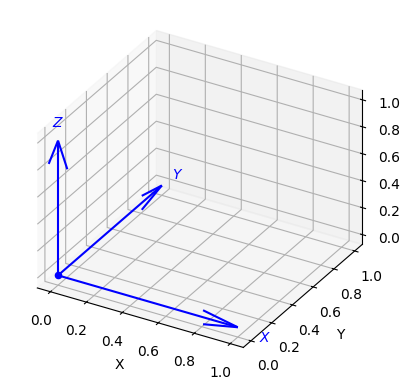

In [2]:
A = rotx(0)
trplot(A)

In [3]:
R = rotx(pi / 2)
R

array([[       1,        0,        0],
       [       0,        0,       -1],
       [       0,        1,        0]])

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

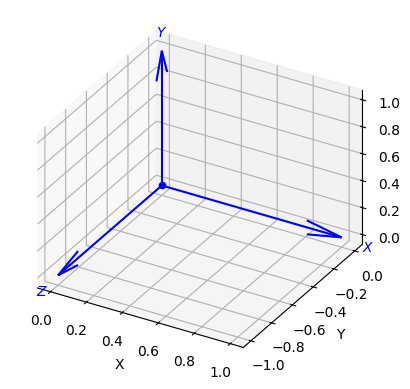

In [4]:
trplot(R)

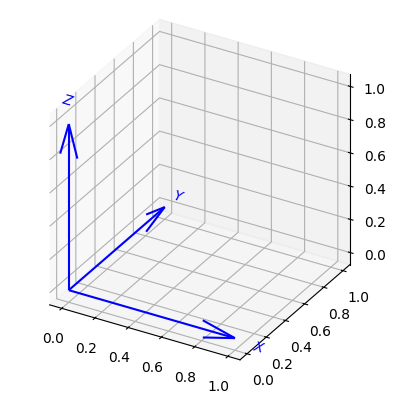

In [5]:
tranimate(R)

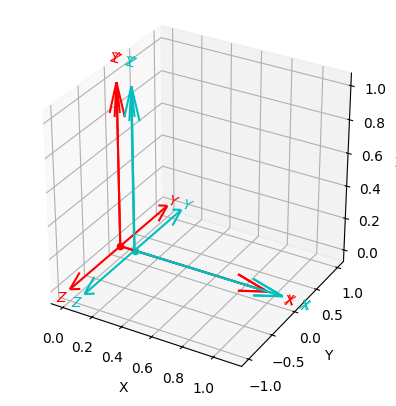

In [6]:
trplot(R, anaglyph=True)
tranimate(R, anaglyph=True)

In [7]:
R = rotx(pi / 2) @ roty(pi / 2)
R

array([[       0,        0,        1],
       [       1,        0,        0],
       [       0,        1,        0]])

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

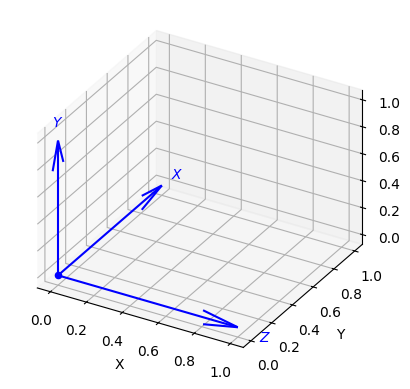

In [8]:
trplot(R)

In [9]:
roty(pi / 2) @ rotx(pi / 2)

array([[       0,        1,        0],
       [       0,        0,       -1],
       [      -1,        0,        0]])

#### Three-Angle Representation

In [10]:
R = rotz(0.1) @ roty(0.2) @ rotz(0.3)
R

array([[  0.9021,  -0.3836,   0.1977],
       [  0.3875,   0.9216,  0.01983],
       [ -0.1898,  0.05871,   0.9801]])

In [11]:
R = eul2r(0.1, 0.2, 0.3)
R

array([[  0.9021,  -0.3836,   0.1977],
       [  0.3875,   0.9216,  0.01983],
       [ -0.1898,  0.05871,   0.9801]])

In [12]:
gamma = tr2eul(R)
gamma

array([     0.1,      0.2,      0.3])

In [13]:
R = eul2r(0.1, -0.2, 0.3)
R

array([[  0.9021,  -0.3836,  -0.1977],
       [  0.3875,   0.9216, -0.01983],
       [  0.1898, -0.05871,   0.9801]])

In [14]:
gamma = tr2eul(R)
gamma

array([  -3.042,      0.2,   -2.842])

In [15]:
eul2r(gamma)

array([[  0.9021,  -0.3836,  -0.1977],
       [  0.3875,   0.9216, -0.01983],
       [  0.1898, -0.05871,   0.9801]])

In [16]:
R = eul2r([0.1, 0, 0.3])
R

array([[  0.9211,  -0.3894,        0],
       [  0.3894,   0.9211,        0],
       [       0,        0,        1]])

In [17]:
tr2eul(R)

array([       0,        0,      0.4])

In [18]:
R = rpy2r(0.1, 0.2, 0.3, order="zyx")
R

array([[  0.9363,  -0.2751,   0.2184],
       [  0.2896,   0.9564, -0.03696],
       [ -0.1987,  0.09784,   0.9752]])

In [19]:
gamma = tr2rpy(R, order="zyx")
gamma

array([     0.1,      0.2,      0.3])

In [20]:
R = rpy2r(0.1, 0.2, 0.3, order="xyz")
R

array([[  0.9752, -0.09784,   0.1987],
       [  0.1538,   0.9447,  -0.2896],
       [ -0.1593,    0.313,   0.9363]])

In [21]:
gamma = tr2rpy(R, order="xyz")
gamma

array([     0.1,      0.2,      0.3])

#### Two-Vector Representation

In [22]:
a = [0, 0, -1]
o = [1, 1, 0]
R = oa2r(o, a)
R

array([[ -0.7071,   0.7071,        0],
       [  0.7071,   0.7071,        0],
       [       0,        0,       -1]])

#### Rotation About an Arbitrary Vector

In [23]:
R = rpy2r(0.1, 0.2, 0.3)
R

array([[  0.9363,  -0.2751,   0.2184],
       [  0.2896,   0.9564, -0.03696],
       [ -0.1987,  0.09784,   0.9752]])

In [24]:
theta, v = tr2angvec(R)
theta

0.3655021863566987

In [25]:
v

array([  0.1886,   0.5834,     0.79])

In [26]:
e, x = np.linalg.eig(R)
e

array([0.93394439+0.35741835j, 0.93394439-0.35741835j, 1.        +0.j        ])

In [27]:
x

array([[ 0.69442042+0.j        ,  0.69442042-0.j        ,  0.18857511+0.j        ],
       [-0.07921035-0.56882404j, -0.07921035+0.56882404j,  0.58337798+0.j        ],
       [-0.10726605+0.42004668j, -0.10726605-0.42004668j,  0.79000605+0.j        ]])

In [28]:
theta = np.angle(e[0])
theta

0.3655021863566988

In [29]:
R = angvec2r(0.3, [1, 0, 0])
R

array([[       1,        0,        0],
       [       0,   0.9553,  -0.2955],
       [       0,   0.2955,   0.9553]])

In [30]:
rotx(0.3)

array([[       1,        0,        0],
       [       0,   0.9553,  -0.2955],
       [       0,   0.2955,   0.9553]])

#### Matrix Exponential for Rotation

In [31]:
R = rotx(0.3)
R

array([[       1,        0,        0],
       [       0,   0.9553,  -0.2955],
       [       0,   0.2955,   0.9553]])

In [32]:

L = linalg.logm(R)
L

array([[       0,        0,        0],
       [       0,        0,     -0.3],
       [       0,      0.3,        0]])

In [33]:
S = vex(L)
S

array([     0.3,        0,        0])

In [34]:
L = trlog(R)
L

array([[       0,        0,        0],
       [       0,        0,     -0.3],
       [       0,      0.3,        0]])

In [35]:
linalg.expm(L)

array([[       1,        0,        0],
       [       0,   0.9553,  -0.2955],
       [       0,   0.2955,   0.9553]])

In [36]:
trexp(L)

array([[       1,        0,        0],
       [       0,   0.9553,  -0.2955],
       [       0,   0.2955,   0.9553]])

In [37]:
linalg.expm(skew(S))

array([[       1,        0,        0],
       [       0,   0.9553,  -0.2955],
       [       0,   0.2955,   0.9553]])

In [38]:
R = rotx(0.3)
R

array([[       1,        0,        0],
       [       0,   0.9553,  -0.2955],
       [       0,   0.2955,   0.9553]])

In [39]:
R = linalg.expm(0.3 * skew([1, 0, 0]))
R

array([[       1,        0,        0],
       [       0,   0.9553,  -0.2955],
       [       0,   0.2955,   0.9553]])

#### Unit Quaternions

In [40]:
q = UnitQuaternion(rpy2r(0.1, 0.2, 0.3))
q

 0.9833 <<  0.0343,  0.1060,  0.1436 >>


In [41]:
q = q * q
q

 0.9339 <<  0.0674,  0.2085,  0.2824 >>


In [42]:
q.inv()

 0.9339 << -0.0674, -0.2085, -0.2824 >>


In [43]:
q * q.inv()

 1.0000 <<  0.0000,  0.0000,  0.0000 >>


In [44]:
q / q

 1.0000 <<  0.0000,  0.0000,  0.0000 >>


In [45]:
q.R

array([[  0.7536,  -0.4993,   0.4275],
       [  0.5555,   0.8315, -0.008145],
       [ -0.3514,   0.2436,    0.904]])

In [46]:
q * [1, 0, 0]

array([  0.7536,   0.5555,  -0.3514])

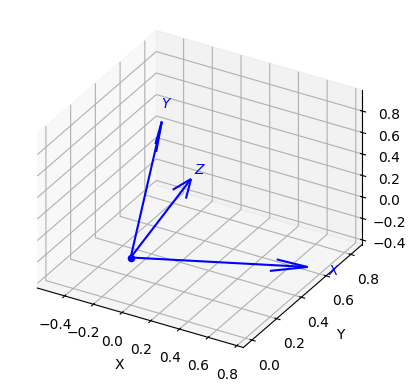

In [47]:
q.plot()

### Pose in Three Dimensions
#### Homogeneous Transformation Matrix

In [48]:
T = transl(2, 0, 0) @ trotx(pi / 2) @ transl(0, 1, 0)
T

array([[       1,        0,        0,        2],
       [       0,        0,       -1,        0],
       [       0,        1,        0,        1],
       [       0,        0,        0,        1]])

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

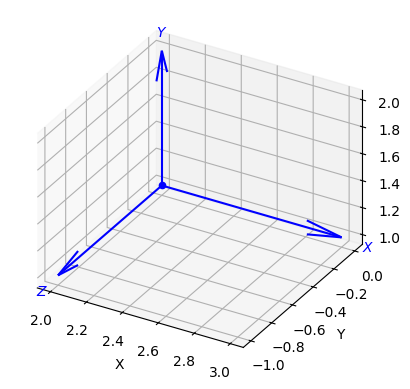

In [49]:
trplot(T)

In [50]:
t2r(T)

array([[       1,        0,        0],
       [       0,        0,       -1],
       [       0,        1,        0]])

In [51]:
transl(T)

array([       2,        0,        1])

#### Matrix Exponential for Pose

In [52]:
T = transl(2, 3, 4) @ trotx(0.3)
T

array([[       1,        0,        0,        2],
       [       0,   0.9553,  -0.2955,        3],
       [       0,   0.2955,   0.9553,        4],
       [       0,        0,        0,        1]])

In [53]:
L = linalg.logm(T)
L

array([[       0,        0,        0,        2],
       [       0,        0,     -0.3,    3.577],
       [       0,      0.3,        0,     3.52],
       [       0,        0,        0,        0]])

In [54]:
S = vexa(L)
S

array([       2,    3.577,     3.52,      0.3,        0,        0])

In [55]:
linalg.expm(skewa(S))

array([[       1,        0,        0,        2],
       [       0,   0.9553,  -0.2955,        3],
       [       0,   0.2955,   0.9553,        4],
       [       0,        0,        0,        1]])

In [56]:
X = skewa([1, 2, 3, 4, 5, 6])
X

array([[       0,       -6,        5,        1],
       [       6,        0,       -4,        2],
       [      -5,        4,        0,        3],
       [       0,        0,        0,        0]])

In [57]:
vexa(X)

array([       1,        2,        3,        4,        5,        6])

In [58]:
S = Twist3.UnitRevolute([1, 0, 0], [0, 0, 0])
S

(0 0 0; 1 0 0)

In [59]:
linalg.expm(0.3 * skewa(S.S))

array([[       1,        0,        0,        0],
       [       0,   0.9553,  -0.2955,        0],
       [       0,   0.2955,   0.9553,        0],
       [       0,        0,        0,        1]])

In [60]:
S.exp(0.3)

   1         0         0         0         
   0         0.9553   -0.2955    0         
   0         0.2955    0.9553    0         
   0         0         0         1         


In [61]:
S = Twist3.UnitRevolute([0, 0, 1], [2, 3, 2], 0.5)
S

(3 -2 0.5; 0 0 1)

In [62]:
X = transl(3, 4, -4)
X

array([[       1,        0,        0,        3],
       [       0,        1,        0,        4],
       [       0,        0,        1,       -4],
       [       0,        0,        0,        1]])

Axes3D(0.125,0.11;0.775x0.77)


[[<mpl_toolkits.mplot3d.art3d.Line3D at 0x1bb8e843d00>]]

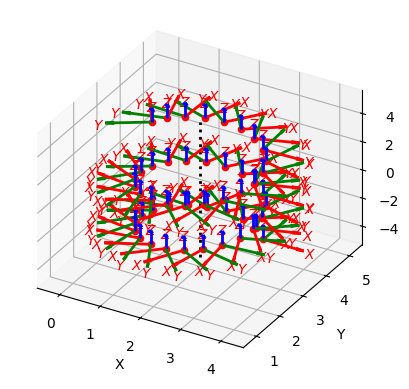

In [66]:
for theta in np.arange(0, 15, 0.3):
    trplot(S.exp(theta).A @ X, style="rgb", width=2)
L.plot("k:", linewidth=2)

In [64]:
L = S.line()
L

{ -3 2 0; 0 0 1}

In [67]:
S = Twist3.UnitPrismatic([0, 1, 0])
S

(0 1 0; 0 0 0)

In [68]:
S.exp(2)

   1         0         0         0         
   0         1         0         2         
   0         0         1         0         
   0         0         0         1         


In [71]:
T = transl(1, 2, 3) @ eul2tr(0.3, 0.4, 0.5)
T

array([[  0.6305,  -0.6812,    0.372,        1],
       [  0.6969,   0.7079,   0.1151,        2],
       [ -0.3417,   0.1867,   0.9211,        3],
       [       0,        0,        0,        1]])

In [72]:
S = Twist3(T)
S

(1.1204 1.6446 3.1778; 0.041006 0.4087 0.78907)

In [73]:
S.w

array([ 0.04101,   0.4087,   0.7891])

In [74]:
S.pole

array([0.001138,   0.8473,  -0.4389])

In [75]:
S.pitch

3.2256216289351296

In [76]:
S.theta

0.8895797456112914

#### Vector-Quaternion Pair